# Bar charts
Bar charts are a common and effective way to visualise categorical data. Each bar represents a category, and the height (or length, in horizontal charts) of the bar corresponds to the value or count associated with that category.

Bar charts are especially useful when comparing discrete groups or tracking changes across categories. They are easy to interpret and can be enhanced with annotations, error bars, or grouping for more complex comparisons.

In [1]:
# %%%%%%%% imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plot_misc.barchart as barchart
import plot_misc.example_data.examples as examples
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

In [2]:
# import example data
table = examples.load_barchart_data()
table = table.T

# constants
COLOURS = ["red", "green", "orange"]
EDGECOLOUR = "black"
TICKS_WD = 0.6
CMTOINCH = 1 / 2.54
LABELS = "labels"

# Adding the index as a column
table["labels"] = table.index
table = table.loc[["Heart failure", "HCM", "DCM", "Non-ischemic CM", "AF"]]

# show table
table.head()

cardiac_chambers,LA,LV,RV,labels
Heart failure,3,6,3,Heart failure
HCM,0,4,4,HCM
DCM,1,6,3,DCM
Non-ischemic CM,0,5,3,Non-ischemic CM
AF,4,5,2,AF


## Stacked bar chart 
Stacked bar charts are a variant of the standard bar chart where multiple data series are stacked on top of one another within each category. This allows you to compare both the total value across categories and the contribution of each sub-group to that total.

They are particularly useful when:
* You want to show how parts make up a whole across categories.
* You want to highlight patterns or differences in group composition.

However, interpretation can become more difficult when there are many segments, especially if they vary subtly in size. In such cases, consider using grouped bar charts as an alternative.

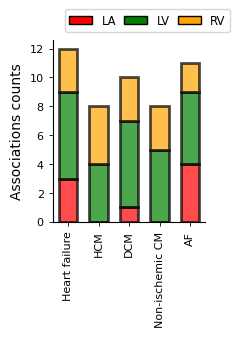

In [3]:
### figure
fig, ax = plt.subplots(
    figsize=(5 * CMTOINCH, 6 * CMTOINCH), nrows=1, sharex=True, sharey=False
)
_, ax = barchart.stack_bar(
    table,
    label=LABELS,
    columns=table.columns[:-1].to_list(),
    wd=0.6,
    edgecolor=EDGECOLOUR,
    colours=COLOURS,
    ax=ax,
    **{"linewidth": 2}
)
### formatting
# x-axis
ax.set_xlim(-0.5, table.shape[0] - 0.5)
# labels and ticks
ax.tick_params(axis="x", labelsize=8.0, length=3, width=TICKS_WD, rotation=90)
ax.tick_params(axis="y", labelsize=8.0, length=3, width=TICKS_WD, rotation=0)
# only integer
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
# remove labels
ax.set_ylabel("Associations counts")
ax.set_xlabel("")
# legend
cmap = dict(zip(list(table.columns[:-1]), COLOURS))
patches = [Patch(facecolor=v, label=k, edgecolor=EDGECOLOUR) for k, v in cmap.items()]
ax.legend(
    handles=patches,
    ncol=3,
    bbox_to_anchor=(1.2, 1.20),
    fancybox=True,
    shadow=False,
    fontsize="small",
    markerscale=0.6,
    columnspacing=0.7,
)

### horizontal bar chart
In the next example we will get the function to internally generate an `axes` object and depict the bar chart horizontally. 

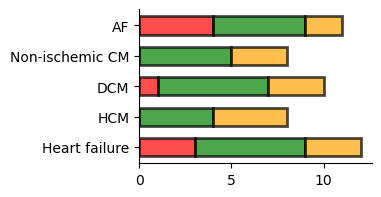

In [4]:
_, ax = barchart.stack_bar(
    table,
    label=LABELS,
    columns=table.columns[:-1].to_list(),
    wd=0.6,
    edgecolor=EDGECOLOUR,
    colours=COLOURS,
    ax=None,
    figsize=(3, 2),
    horizontal=True,
    **{"linewidth": 2}
)

## Regular bar chart
A simple bar chart is the most basic form of bar visualisation. It displays a single value for each category using bars of varying height (or length).

Each bar:
* Represents one category on the x-axis.
* Has a height proportional to the numeric value on the y-axis.

This type of chart is ideal for quickly comparing individual values across categories, such as counts, totals, or summary statistics. Simple bar charts are easy to interpret and widely used in exploratory data analysis and reporting.

Here we will add some error bars, specifically only providing the top error bar. To maximise flexibility the function assumes the error limits are pre-computed instead of internally calculating these. 

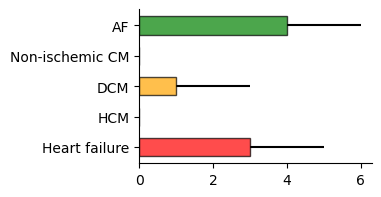

In [5]:
# Reusing the previous data
table_s = table.copy()
table_s[LABELS] = table.index
column = table_s.columns.to_list()[0]
# introducing an error column
error_max = "max"
table_s[error_max] = [v + 2 if v > 0 else 0 for v in table_s[column]]

# plotting
_, ax = barchart.bar(
    table_s,
    label=LABELS,
    column=column,
    error_max=error_max,
    wd=0.6,
    colours=["red", "green", "orange"],
    ax=None,
    figsize=(3, 2),
    horizontal=True,
)

## Bar chart with a total and subtotal column
This type of bar chart displays two overlapping layers of information for each category:
* The total value is shown as a wider, lighter-coloured bar in the background.
* The subtotal (a component or subset of the total) is overlaid as a narrower, more saturated bar.

By plotting subtotals on top of totals, this chart:
* Clearly communicates both the absolute value (total) and the contribution of a specific subgroup (subtotal).
* Enables comparison of relative proportions within and across categories.
* Preserves a clean layout without requiring stacking or grouping.

In [6]:
# Creating some toy data
data_w = examples.load_barchart_data()
data = data_w.T.copy()
label = "labels"
total_col = "total"
subtotal_col = "sub"
data[label] = data_w.T.index
data[total_col] = data.drop(columns=[label]).sum(axis=1)
data[subtotal_col] = data["LV"]
data.drop(labels=["LA", "LV", "RV"], inplace=True, axis=1)
data.sort_values(by=total_col, ascending=True, inplace=True)
data

cardiac_chambers,labels,total,sub
HCM,HCM,8,4
Non-ischemic CM,Non-ischemic CM,8,5
DCM,DCM,10,6
AF,AF,11,5
Heart failure,Heart failure,12,6


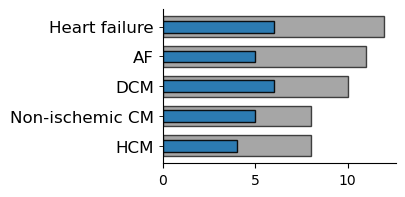

In [7]:
# plotting the graph
_, ax = barchart.subtotal_bar(
    data,
    label=label,
    total_col=total_col,
    subtotal_col=subtotal_col,
    wd=(0.7, 0.4),
    figsize=(3, 2),
    horizontal=True,
)
ax.tick_params(axis="y", labelsize=12.0, length=3, width=TICKS_WD, rotation=00)

### Now plotting as a base and stem visual
Next we will make the subtotal bar wider than the total bar to give a base and stem visual. 

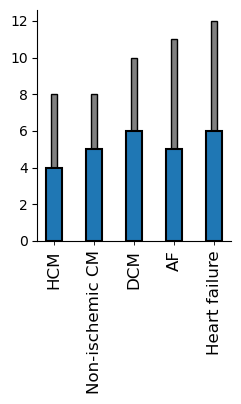

In [8]:
# plotting the graph
_, ax = barchart.subtotal_bar(
    data,
    label=label,
    total_col=total_col,
    subtotal_col=subtotal_col,
    wd=(0.15, 0.4),
    transparency=(1.0, 1.0),
    figsize=(2.5, 3),
    horizontal=False,
    total_kwargs_dict={"linewidth": 1.0},
    subtotal_kwargs_dict={"linewidth": 1.5},
)
ax.tick_params(axis="x", labelsize=12.0, length=3, width=TICKS_WD, rotation=90)

## Grouped bar chart 
Grouped bar charts display multiple bars per category, allowing comparison of subgroups (e.g. time points or conditions) side by side. Each group shares a common axis label, with distinct bars representing different variables. This is useful for visualising repeated measures or comparing conditions across individuals. Error bars can be added to show uncertainty.

In [9]:
# import example data
group_table = examples.load_groupbar_data()

# constants
COLOURS = ["white"] + COLOURS
GENES = ["Control", "AP4S1", "LRRC39", "ZFAND4"]
BWID = 0.2
LWID = 1
col_dic = {k: v for k, v in zip(GENES, COLOURS)}

# columns to plot
cols = [x + "_mean" for x in GENES]
errs = [x + "_max" for x in GENES]

# HACKY HACK HACK adding an example max error columns
for col in group_table.columns:
    if col.endswith("_mean"):
        base = col.removesuffix("_mean")
        std_col = f"{base}_std"
        if std_col in group_table.columns:
            group_table[f"{base}_max"] = group_table[col] + group_table[std_col]

# show table that will create the bars
group_table.head()

,Age,AP4S1_mean,Control_mean,LRRC39_mean,ZFAND4_mean,AP4S1_std,Control_std,LRRC39_std,ZFAND4_std,AP4S1_max,Control_max,LRRC39_max,ZFAND4_max
0,Day 13,29.555556,14.444444,30.333333,32.333333,11.402972,9.015419,16.568042,15.288885,40.958528,23.459863,46.901375,47.622218
1,Day 27,37.222222,16.444444,32.333333,37.777778,15.610716,12.217929,12.439855,15.682616,52.832938,28.662373,44.773189,53.460394


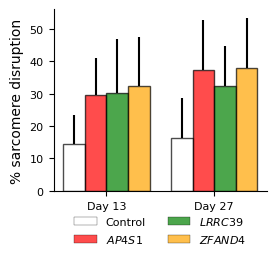

In [10]:
fig, ax = plt.subplots(
    figsize=(7 * CMTOINCH, 6 * CMTOINCH), nrows=1, sharex=True, sharey=False
)
_, _ = barchart.group_bar(
    group_table,
    label="Age",
    columns=cols,
    colours=COLOURS,
    errors_max=errs,
    transparency=0.7,
    wd=BWID,
    ax=ax,
)

# Lay-out
col_dic_it = {k if k == "Control" else rf"$\it{{{k}}}$": v for k, v in col_dic.items()}
ax.tick_params(axis="both", labelsize=8)
ax.set_ylabel("% sarcomere disruption")

# legend
patches = [
    Patch(facecolor=v, label=k, edgecolor="black", lw=0.3, alpha=0.7)
    for k, v in col_dic_it.items()
]
legend = ax.legend(
    handles=patches,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.35),
    frameon=False,
    shadow=False,
    fontsize=8,
    markerscale=0.6,
)
legend.get_frame().set_linewidth(LWID)

### Horizontal grouped bar chart with additional spacing

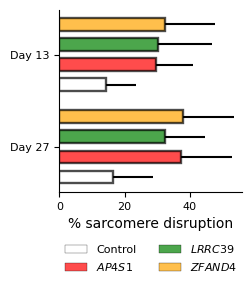

In [11]:
fig, ax = plt.subplots(
    figsize=(6 * CMTOINCH, 6 * CMTOINCH), nrows=1, sharex=True, sharey=False
)
_, _ = barchart.group_bar(
    group_table.iloc[::-1],
    label="Age",
    columns=cols,
    colours=COLOURS,
    errors_max=errs,
    transparency=0.7,
    wd=0.15,
    bar_spacing=0.6,
    group_spacing=1.1,
    horizontal=True,
    ax=ax,
    kwargs_bar={"linewidth": 1.7},
)

# Lay-out
col_dic_it = {k if k == "Control" else rf"$\it{{{k}}}$": v for k, v in col_dic.items()}
ax.tick_params(axis="both", labelsize=8)
ax.set_xlabel("% sarcomere disruption")

# legend
patches = [
    Patch(facecolor=v, label=k, edgecolor="black", lw=0.3, alpha=0.7)
    for k, v in col_dic_it.items()
]
legend = ax.legend(
    handles=patches,
    loc="lower center",
    ncol=2,
    bbox_to_anchor=(0.5, -0.5),
    frameon=False,
    shadow=False,
    fontsize=8,
    markerscale=0.6,
)
legend.get_frame().set_linewidth(LWID)